# 01. Importing Libraries

In [88]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

from xgboost import XGBClassifier
import joblib

import time
import pycountry_convert as pc

# 02. Importing Data

In [2]:
data = pd.read_csv('../01. Data/hotel_booking_clean_data.csv')

In [3]:
# checking data import
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,3,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,4,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,C,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# checking for possible imbalance in the target - to be checked again in a confusion matrix after model selection
# not a clear imbalance, but might worth to check for future models
data['is_canceled'].value_counts(normalize = True)

is_canceled
0    0.724061
1    0.275939
Name: proportion, dtype: float64

#### Renaming columns and doing some checkings in the data

In [5]:
# changing columns name for easy comprehension
data = data.rename(columns={'adr': 'average_daily_rate'})

In [6]:
# checking values in reservation_status
data['reservation_status'].value_counts()

reservation_status
Check-Out    62931
Canceled     22973
No-Show       1010
Name: count, dtype: int64

In [7]:
# checking if reservation_status column is correlated to is_canceled
data[data['reservation_status'].isin(['Canceled', 'No-Show'])]['is_canceled'].value_counts()

is_canceled
1    23983
Name: count, dtype: int64

In [8]:
# checking if reservation_status column is correlated to is_canceled
data[data['reservation_status'].isin(['Check-Out'])]['is_canceled'].value_counts()

is_canceled
0    62931
Name: count, dtype: int64

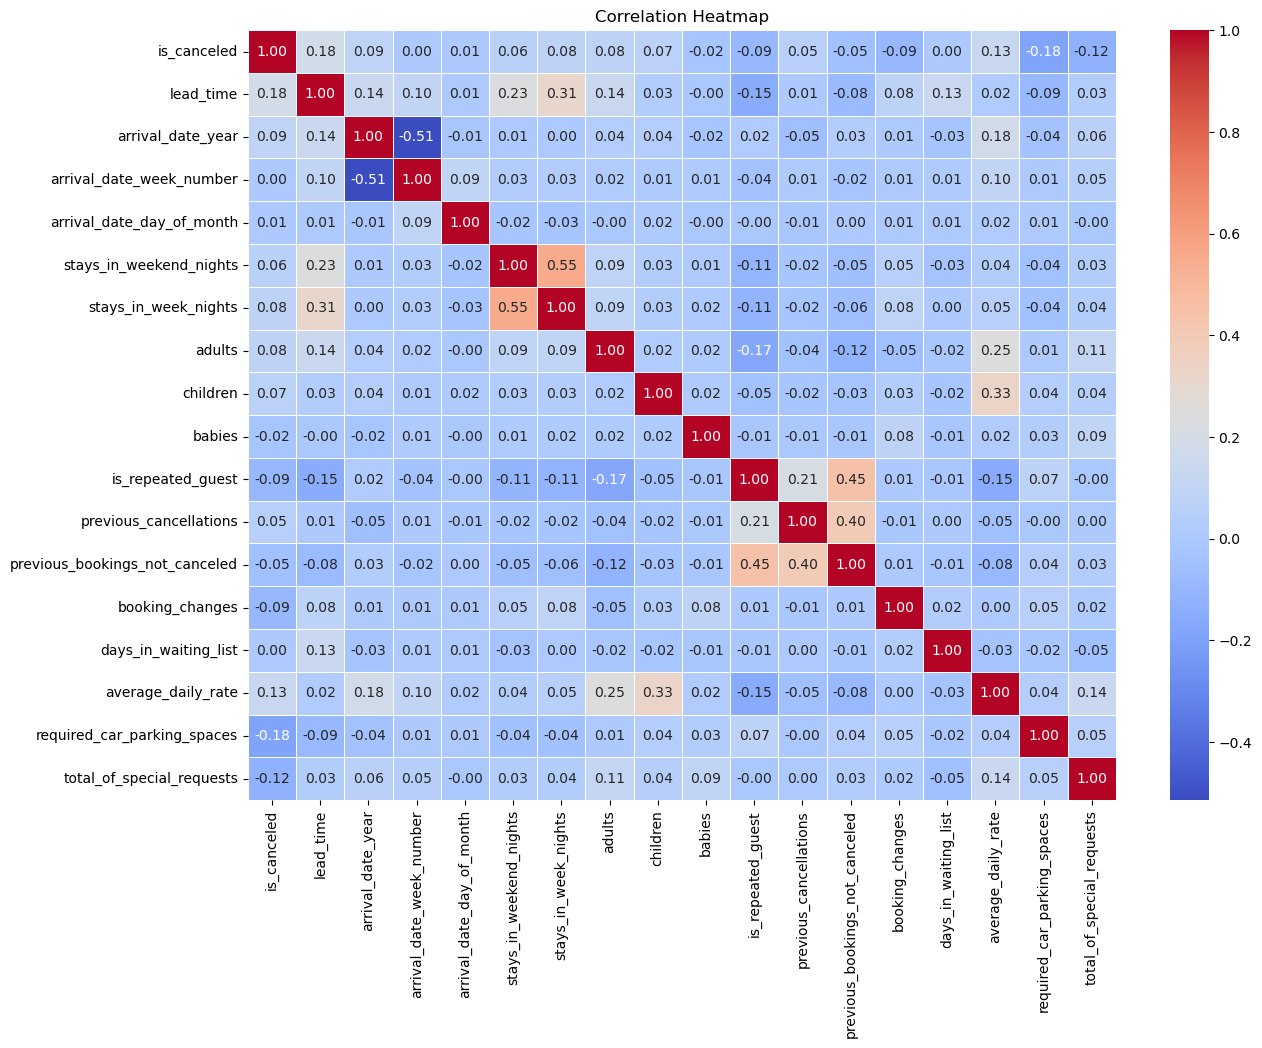

In [9]:
# checking correlation on numeric data to check columns to drop
numeric_data = data.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_data.corr(),
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [11]:
# checking the above in a list
correlation = data.select_dtypes(exclude='object').corr()['is_canceled'].abs().sort_values(ascending = False)
correlation

is_canceled                       1.000000
required_car_parking_spaces       0.183751
lead_time                         0.183683
average_daily_rate                0.126671
total_of_special_requests         0.121825
booking_changes                   0.094074
is_repeated_guest                 0.090171
arrival_date_year                 0.087745
stays_in_week_nights              0.082778
adults                            0.080216
children                          0.067010
stays_in_weekend_nights           0.059596
previous_cancellations            0.050964
previous_bookings_not_canceled    0.050567
babies                            0.020950
arrival_date_day_of_month         0.005227
days_in_waiting_list              0.004297
arrival_date_week_number          0.000795
Name: is_canceled, dtype: float64

# 03. Performing Train Test Split

In [12]:
# defining features and target
features = data.drop(columns = ['is_canceled'])
target = data['is_canceled']

In [13]:
# separating the test and train sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.2, random_state = 17)

In [14]:
# checking if sizes are equal
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(69531, 29)
(17383, 29)
(69531,)
(17383,)


# 04.1 Transformations in Train Split

In [15]:
X_train.head()

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,average_daily_rate,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
23499,Resort Hotel,4,2017,March,12,21,0,1,1,0.0,...,D,0,No Deposit,0,Transient,63.00,0,0,Check-Out,2017-03-22
44476,City Hotel,15,2016,November,47,17,2,4,2,0.0,...,A,0,No Deposit,0,Transient,92.50,0,0,Canceled,2016-11-11
74148,City Hotel,71,2017,January,1,2,1,3,2,0.0,...,A,0,No Deposit,0,Transient,97.40,1,2,Check-Out,2017-01-06
37800,City Hotel,45,2016,March,11,7,1,3,2,0.0,...,A,0,No Deposit,0,Transient,63.75,0,0,Canceled,2016-02-21
42025,City Hotel,110,2016,August,34,15,1,3,2,0.0,...,A,0,No Deposit,0,Transient,117.90,0,0,Canceled,2016-05-11


In [16]:
# checking data types
X_train.dtypes

hotel                              object
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
days_in_waiting_list                int64
customer_type                     

In [17]:
# getting only the columns with data types object for exploration
X_train.select_dtypes(include='object').columns

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='object')

In [18]:
# getting the unique values of columns with type 'object' 
for col in X_train.select_dtypes(include='object').columns:
    print(col, X_train[col].unique())

hotel ['Resort Hotel' 'City Hotel']
arrival_date_month ['March' 'November' 'January' 'August' 'September' 'June' 'October'
 'December' 'July' 'April' 'May' 'February']
meal ['BB' 'SC' 'Undefined' 'HB' 'FB']
country ['PRT' 'RUS' 'ESP' 'CHE' 'DEU' 'AUS' 'GBR' 'FRA' 'PHL' 'IRL' 'NLD' 'BEL'
 'ROU' 'ITA' 'USA' 'MEX' 'NOR' 'POL' 'SWE' 'CZE' 'BRA' 'HRV' 'MAR' 'TUR'
 'UGA' 'PER' 'ISR' 'JPN' 'AGO' 'SRB' 'ARG' 'CN' 'UKR' 'CHN' 'HUN' 'GRC'
 'SVK' 'LUX' 'DNK' 'DZA' 'THA' 'LTU' 'KOR' 'SAU' 'AUT' 'FIN' 'IND' 'PAK'
 'AZE' 'MOZ' 'NZL' 'ZAF' 'VEN' 'PAN' 'IRN' 'EST' 'CRI' 'COL' 'MUS' 'TWN'
 'MYS' 'CIV' 'CPV' 'MCO' 'LVA' 'IDN' 'KAZ' 'SVN' 'CHL' 'ARE' 'QAT' 'URY'
 'EGY' 'DOM' 'ISL' 'CYP' 'KWT' 'AND' 'TUN' 'OMN' 'CUB' 'CMR' 'LBN' 'NGA'
 'BGR' 'GHA' 'ASM' 'MAC' 'TZA' 'BLR' 'CYM' 'MLT' 'SUR' 'ECU' 'HKG' 'SGP'
 'PRI' 'BGD' 'MKD' 'IRQ' 'ARM' 'JEY' 'JAM' 'JOR' 'ZWE' 'LKA' 'BIH' 'KIR'
 'GUY' 'DJI' 'SEN' 'MNE' 'GTM' 'FRO' 'MYT' 'LBY' 'GNB' 'STP' 'VNM' 'MDV'
 'KHM' 'MRT' 'BEN' 'PRY' 'RWA' 'GAB' 'BHR' 'SLV' 'KEN' '

In [19]:
# defining function to convert countries to continents
def get_continent(country_code):
    try:
        continent_code = pc.country_alpha2_to_continent_code(
            pc.country_alpha3_to_country_alpha2(country_code)
        )
        continent_map = {
            'AF': 'Africa', 'AS': 'Asia', 'EU': 'Europe',
            'NA': 'North America', 'SA': 'South America',
            'OC': 'Oceania', 'AN': 'Antarctica'
        }
        return continent_map[continent_code]
    except:
        return 'Unknown'

def encode_country(df):
    df['continent'] = df['country'].apply(get_continent)
    df = df.drop(columns=['country'])
    return df 

In [20]:
# defining function for substituing months for numbers
def encode_month(df):
    month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
    df['arrival_date_month'] = df['arrival_date_month'].map(month_map)
    return df

In [21]:
# defining drop reservation_status_date, assigned_room_type, reservation_status
def drop_columms(df):
    df = df.drop(columns=['reservation_status_date', 'assigned_room_type', 'reservation_status'])
    return df

In [22]:
# calling the functions above for initial transformations
X_train = encode_country(X_train)
X_train = encode_month(X_train)
X_train = drop_columms(X_train)

In [23]:
# checking all values of the columns to be able to map them without creating nulls (missing continent, as it was done after splitting)

cat_cols = ['hotel', 'meal', 'continent', 'market_segment', 'distribution_channel', 
            'reserved_room_type', 'deposit_type', 'customer_type']

for col in ['hotel', 'meal', 'market_segment', 'distribution_channel', 
            'reserved_room_type', 'deposit_type', 'customer_type']:
    print(f"{col}: {data[col].unique()}\n")

hotel: ['Resort Hotel' 'City Hotel']

meal: ['BB' 'FB' 'HB' 'SC' 'Undefined']

market_segment: ['Direct' 'Corporate' 'Online TA' 'Offline TA/TO' 'Complementary' 'Groups'
 'Aviation']

distribution_channel: ['Direct' 'Corporate' 'TA/TO' 'Undefined' 'GDS']

reserved_room_type: ['C' 'A' 'D' 'E' 'G' 'F' 'H' 'L' 'B' 'P']

deposit_type: ['No Deposit' 'Refundable' 'Non Refund']

customer_type: ['Transient' 'Contract' 'Transient-Party' 'Group']



In [24]:
def label_encoding(df):
    df['hotel'] = df['hotel'].map({'Resort Hotel': 0, 'City Hotel': 1})
    df['meal'] = df['meal'].map({'BB': 0, 'SC': 1, 'Undefined': 2, 'HB': 3, 'FB': 4})

    df['continent'] = df['continent'].map({'Europe': 0, 'Oceania': 1, 'Asia': 2, 
                                        'North America': 3, 'South America': 4, 
                                        'Africa': 5, 'Unknown': 6, 'Antarctica': 7})
    df['market_segment'] = df['market_segment'].map({'Corporate': 0, 'Online TA': 1, 
                                                  'Direct': 2, 'Offline TA/TO': 3, 
                                                  'Groups': 4, 'Aviation': 5, 
                                                  'Complementary': 6})
    df['distribution_channel'] = df['distribution_channel'].map({'Direct': 0, 'TA/TO': 1, 
                                                              'Corporate': 2, 'GDS': 3, 'Undefined': 4})
    df['reserved_room_type'] = df['reserved_room_type'].map({'A': 0, 'D': 1, 'B': 2, 
                                                          'F': 3, 'G': 4, 'E': 5, 
                                                          'C': 6, 'H': 7, 'L': 8, 'P': 9})
    df['deposit_type'] = df['deposit_type'].map({'No Deposit': 0, 'Non Refund': 1, 
                                              'Refundable': 2})
    df['customer_type'] = df['customer_type'].map({'Transient': 0, 'Transient-Party': 1, 
                                                'Contract': 2, 'Group': 3})
    return df

In [25]:
# Performing label encoding in X_train
X_train = label_encoding(X_train)

In [26]:
# normalizing the data fit
normalizer = StandardScaler()
normalizer.fit(X_train)

# normalizing the data function calling for X_train
X_train_norm = pd.DataFrame(normalizer.transform(X_train), columns=X_train.columns)

# 04.2 Transformations in Test Split

In [27]:
# do all transformations in test
X_test = encode_country(X_test)
X_test = encode_month(X_test)
X_test = drop_columms(X_test)
X_test = label_encoding(X_test)
X_test_norm = pd.DataFrame(normalizer.transform(X_test), columns=X_test.columns)

# 05. Model Fitting

### Target is yes or no answer (binary to 0 and 1). Models need to be classifier models to test

#### KNN Classifier

In [28]:
knn_class = KNeighborsClassifier(n_neighbors = 10)

In [29]:
knn_class.fit(X_train_norm, y_train)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


#### Logaritimic Regression

In [30]:
log_reg = LogisticRegression()

In [31]:
log_reg.fit(X_train_norm, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### DecisionTreeClassifier

In [32]:
tree_class = DecisionTreeClassifier(max_depth = 20)

In [33]:
tree_class.fit(X_train_norm, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### BaggingClassifier

In [34]:
bagging_class = BaggingClassifier(DecisionTreeClassifier(max_depth = 20), 
                n_estimators = 100, # number of trees, in this case
                max_samples = 1000) # number of datapoints for each estimator

In [35]:
bagging_class.fit(X_train_norm, y_train)

,estimator,DecisionTreeC...(max_depth=20)
,n_estimators,100
,max_samples,1000
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


#### RandomForestClassifier

In [36]:
forest_class = RandomForestClassifier(n_estimators = 100, # number of trees, in this case
                max_depth = 20)

In [37]:
forest_class.fit(X_train_norm, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### AdaBoostClassifier

In [38]:
ada_class = AdaBoostClassifier(DecisionTreeClassifier(max_depth = 20), 
                n_estimators = 100) # number of trees, in this case

In [39]:
ada_class.fit(X_train_norm, y_train)

,estimator,DecisionTreeC...(max_depth=20)
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None
,criterion,'gini'
,splitter,'best'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


#### GradientBoostingClassifier

In [68]:
gradient_class = GradientBoostingClassifier(max_depth = 20, 
                n_estimators = 100) # number of trees, in this case

In [69]:
gradient_class.fit(X_train_norm, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,20
,min_impurity_decrease,0.0
,init,None


#### XGBClassifier

In [42]:
xgb_class = XGBClassifier(booster = 'gbtree', 
                learning_rate = 0.1, 
                max_depth = 5, 
                n_estimators = 100) 

In [43]:
xgb_class.fit(X_train_norm, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### ExtraTreesClassifier

In [44]:
extra_trees_class = ExtraTreesClassifier()

In [45]:
extra_trees_class.fit(X_train_norm, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


# 06. Evaluating Models Performance

In [46]:
knn_score = knn_class.score(X_test_norm, y_test)
log_score = log_reg.score(X_test_norm, y_test)
tree_score = tree_class.score(X_test_norm, y_test)
bagging_score = bagging_class.score(X_test_norm, y_test)
forest_score = forest_class.score(X_test_norm, y_test)
ada_score = ada_class.score(X_test_norm, y_test)
gradient_score = gradient_class.score(X_test_norm, y_test)
xgb_score = xgb_class.score(X_test_norm, y_test)
extre_trees_score = extra_trees_class.score(X_test_norm, y_test)

In [47]:
# model comparison as dataframe for sorting
models = [
    ('KNN', knn_class),
    ('Logistic Regression', log_reg),
    ('Decision Tree', tree_class),
    ('Bagging', bagging_class),
    ('Random Forest', forest_class),
    ('AdaBoost', ada_class),
    ('Gradient Boosting', gradient_class),
    ('XGB', xgb_class),
    ('Extra Trees', extra_trees_class),
]

results = []

for name, model in models:
    y_pred = model.predict(X_test_norm)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

pd.DataFrame(results).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.810505,0.703912,0.545473,0.614647
1,Extra Trees,0.811943,0.712909,0.537791,0.613090
2,Random Forest,0.815509,0.744158,0.509136,0.604611
3,AdaBoost,0.799574,0.675355,0.532600,0.595542
4,XGB,0.805327,0.725441,0.478405,0.576577
5,Decision Tree,0.771789,0.603511,0.513912,0.555119
6,Bagging,0.799459,0.722111,0.448920,0.553649
7,KNN,0.789910,0.694649,0.431271,0.532155
8,Logistic Regression,0.774320,0.696264,0.328904,0.446764


## Feature Selection based on top model - test to decide if dropping more columns would make the model more accurate

In [48]:
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gradient_class.feature_importances_
})
importances.sort_values(by='Importance', ascending=False)

,Feature,Importance
1,lead_time,0.202644
22,average_daily_rate,0.145014
5,arrival_date_day_of_month,0.092270
4,arrival_date_week_number,0.075689
24,total_of_special_requests,0.068417
7,stays_in_week_nights,0.053208
12,market_segment,0.047128
19,deposit_type,0.036371
23,required_car_parking_spaces,0.029402
6,stays_in_weekend_nights,0.028739


In [62]:
# dropping columns in test and train with less than 0.01
X_train_reduced = X_train_norm.drop(columns=['children', 'distribution_channel', 'is_repeated_guest', 'days_in_waiting_list', 'babies', 'previous_bookings_not_canceled'])
X_test_reduced = X_test_norm.drop(columns=['children', 'distribution_channel', 'is_repeated_guest', 'days_in_waiting_list', 'babies', 'previous_bookings_not_canceled'])

In [63]:
# Retrainig top model with new X_train_reduced
gradient_class_reduced = GradientBoostingClassifier(max_depth = 20, 
                n_estimators = 100)
gradient_class_reduced.fit(X_train_reduced, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,20
,min_impurity_decrease,0.0
,init,None


In [74]:
# comparing same model before and after the reduction

results_comparison = []
for name, model, X_test_input in [
    ('Gradient Boosting (original)', gradient_class, X_test_norm), 
    ('Gradient Boosting (reduced)', gradient_class_reduced, X_test_reduced)]:
    
    y_pred = model.predict(X_test_input)
    results_comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })
pd.DataFrame(results_comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting (original),0.811252,0.705819,0.546512,0.616033
1,Gradient Boosting (reduced),0.810217,0.703079,0.545266,0.614197


### The Model has not improved with dropped columns, so for hyperparameter and future, I will be using the norm sets, not the reduced ones

# 07. Hyperparameter tuning

In [71]:
# random search
grid = {
    "n_estimators": [100, 250, 500],
    "max_leaf_nodes": [100, 250, 500],
    "max_depth": [5, 10, 20]
}
gradient_class_tuning = GradientBoostingClassifier()
model_rand = RandomizedSearchCV(estimator=gradient_class_tuning, param_distributions=grid, cv=5, n_iter=10)

In [75]:
start_time = time.time()
model_rand.fit(X_train_norm, y_train)
end_time = time.time()

print(end_time - start_time)

6581.28582572937


In [80]:
print("Best parameters:", model_rand.best_params_)

Best parameters: {'n_estimators': 250, 'max_leaf_nodes': 100, 'max_depth': 10}


In [76]:
best_model_rand = model_rand.best_estimator_

In [77]:
y_pred = best_model_rand.predict(X_test_norm)

results_tuning = pd.DataFrame([{
    'Model': 'Gradient Boosting (tuned)',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred)
}])

results_tuning

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting (tuned),0.819536,0.737751,0.540905,0.624176


### The tuned model increased the F1 Score by 0.01 point

# 08. Model Export

In [84]:
joblib.dump(best_model_rand, '../03. Models/best_model_gradient_boosting.pkl')

['../03. Models/best_model_gradient_boosting.pkl']

# 09. Confusion Matrix

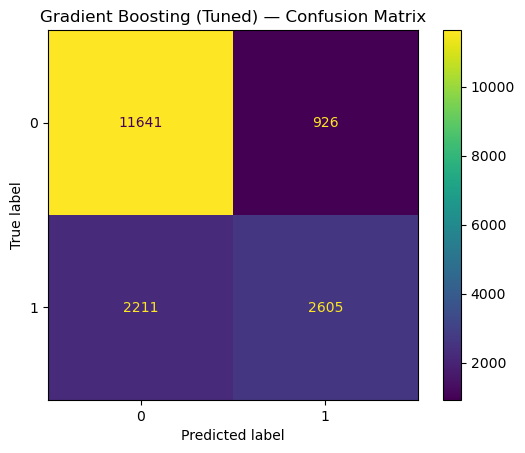

In [89]:
y_pred = best_model_rand.predict(X_test_norm)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Gradient Boosting (Tuned) — Confusion Matrix")
plt.show()